# Temporal role GNN component ablations

This studybook returns to notebook `06`'s fixed-decay temporal role GNN after notebooks `07`–`09` established the rolling validation environment and evaluated attention. It assumes you understand the four causal relation channels, but it does not assume familiarity with ablation design. We will verify the empty-history fallback, remove relation-specific parameters, vary the recency prior, and interpret paired-seed evidence without consulting development-test or sealed-holdout labels.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from graph_ml.viz import (
    plot_paired_decay_ablation,
    plot_paired_recent_ablation,
    plot_paired_relation_ablation,
    plot_temporal_decay_curve,
    plot_temporal_message_schematic,
)

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
RESULTS = ROOT / 'results'

## 1. What exactly is being ablated?

An ablation changes one modelling assumption while keeping the causal dataset, fold, optimizer, and seed set fixed. The temporal role GNN first builds four strictly-prior summaries: current seller through seller-role events, current seller through buyer-role events, and the analogous two paths for the current buyer. For relation $r$, it computes

$$m_{ir}=W_r c_{ir}+U_r z_{ir},\qquad g_{ir}=\sigma(G_r z_{ir}),\qquad h_i=W_0x_i+\sum_r g_{ir}\odot m_{ir},$$

where $c_{ir}$ is the decayed feature mean and $z_{ir}$ contains log count, log age of the newest prior event, and a history-present flag. The gate is a vector, so each hidden dimension can suppress or retain a relation differently. This is still one message-passing layer: histories summarize earlier invoice neighbours connected through a company endpoint.

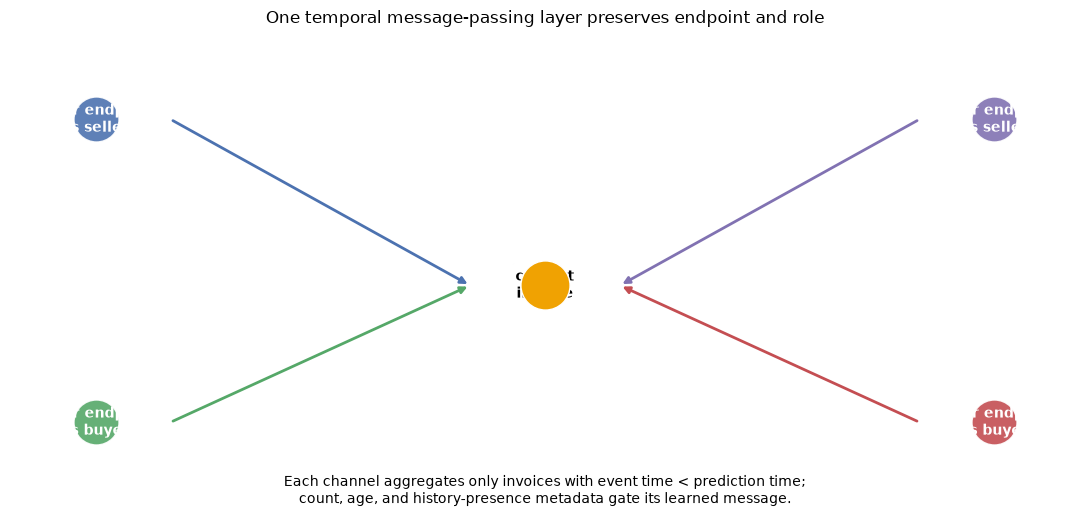

In [2]:
plot_temporal_message_schematic()
plt.show()

## 2. Empty history is already an exact root fallback

When a relation has no strictly-prior event, its context is zero and its three metadata values are zero. Both message transforms have `bias=False`, hence $m_{ir}=0$. The sigmoid gate may be nonzero, but $g_{ir}\odot0=0$. With all four relations empty, the representation before normalization is exactly $W_0x_i$. A unit test compares the model output with this manually evaluated root path.

This rules out one suspected bug: cold-start weakness is not caused by fake padding or a learned empty-history embedding. Partial histories can still be noisy, and separately trained root-only and graph models can reach different optima, but fully empty context cannot directly change a logit through the message path.

## 3. Do the four roles need different parameters?

The default uses separate $W_r$, $U_r$, and $G_r$ for each relation. This encodes the hypothesis that seller history and buyer history have different meanings. The shared control uses one transform and one gate for all four channels. It still computes each causal history separately, but summation becomes invariant to permuting the relation labels.

This is a parameter-sharing test, not a test of removing the graph: shared relations still use company-mediated histories. It reduces fold-1 parameters from 9,217 to 6,145 and fold-2 parameters from 10,177 to 6,529 because categorical feature width is fold-local.

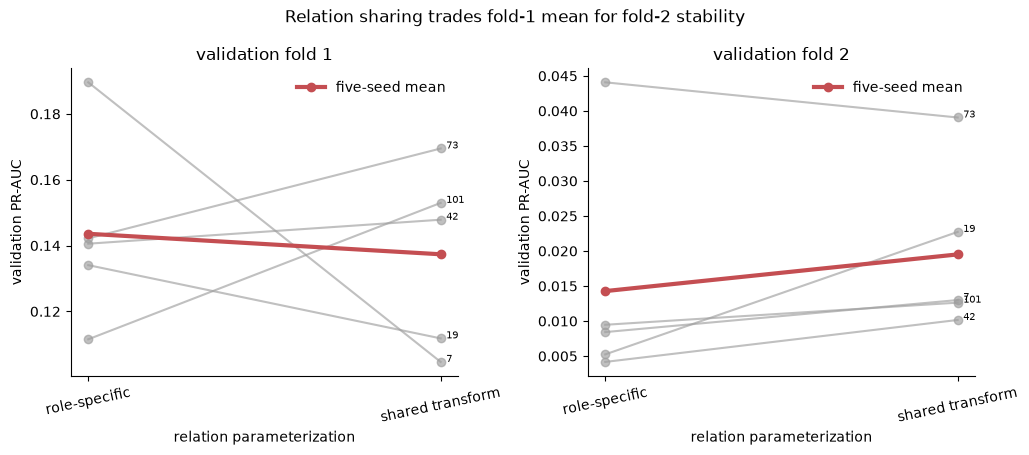

fold,relation_mode,mean,median,std,min,max
1,separate,0.1436,0.1406,0.0285,0.1115,0.1896
1,shared,0.1374,0.1479,0.0279,0.1047,0.1695
2,separate,0.0143,0.0084,0.0168,0.0042,0.0441
2,shared,0.0195,0.0130,0.0119,0.0102,0.0391


In [3]:
relation = pd.read_csv(RESULTS / 'temporal_gnn_relation_ablation.csv')
plot_paired_relation_ablation(relation)
plt.show()
relation_summary = relation.groupby(['fold', 'relation_mode'])['validation_pr_auc'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).reset_index()
display(relation_summary.style.format({
    name: '{:.4f}' for name in ('mean', 'median', 'std', 'min', 'max')
}).hide(axis='index'))

Separate roles have the higher fold-1 mean (0.1436 versus 0.1374), while sharing has the higher median in both folds and the higher fold-2 mean (0.0195 versus 0.0143). Shared transforms also reduce fold-2 spread. This is evidence that relation-specific parameters are not consistently necessary, but it is not a clean promotion: mean ordering still changes by origin. The predeclared separate model remains frozen while shared transforms stay a simpler candidate for future origins.

## 4. What does the half-life control?

A historical event of age $\Delta t$ receives unnormalized weight

$$w(\Delta t)=2^{-\Delta t/H}=\exp[-\log(2)\Delta t/H],$$

where $H$ is the half-life. At 60 days a 60-day-old event has half the weight of a current event; at 180 days the same event retains about 79%. The weighted mean divides by total weight, so decay changes the relative mixture rather than simply shrinking a whole message. Infinite half-life gives weight one to every legal event and is an exact no-decay mean. Strict `< query time` eligibility is unchanged in every treatment.

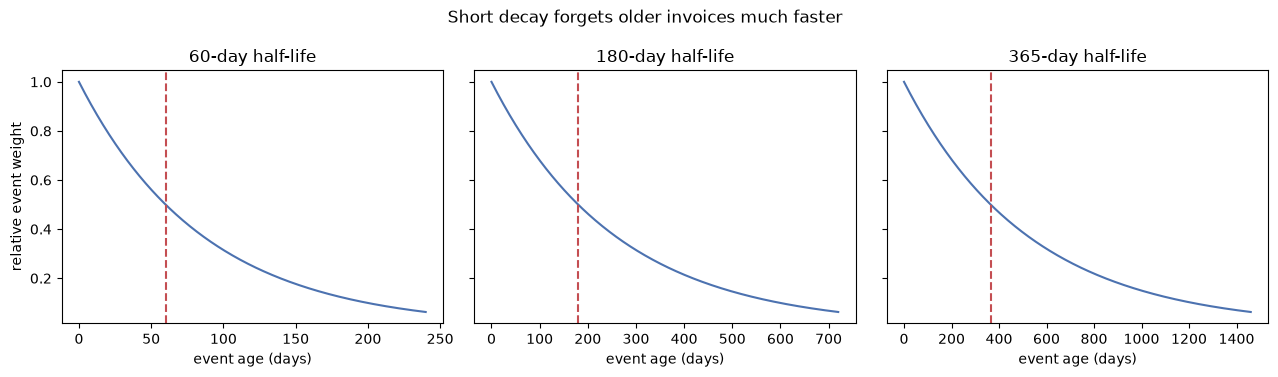

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for axis, half_life in zip(axes, (60, 180, 365), strict=True):
    decay_figure = plot_temporal_decay_curve(half_life_days=half_life)
    line = decay_figure.axes[0].lines[0]
    axis.plot(line.get_xdata(), line.get_ydata(), color='#4C72B0')
    axis.axvline(half_life, color='#C44E52', linestyle='--')
    axis.set(title=f'{half_life}-day half-life', xlabel='event age (days)')
    plt.close(decay_figure)
axes[0].set_ylabel('relative event weight')
figure.suptitle('Short decay forgets older invoices much faster')
figure.tight_layout(); plt.show()

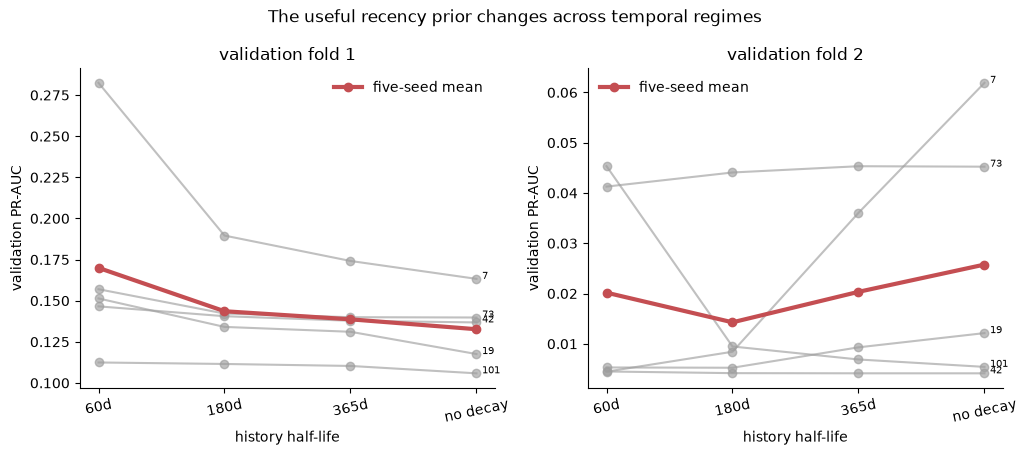

fold,decay,mean,median,std,min,max
1,current_180d,0.1436,0.1406,0.0285,0.1115,0.1896
1,long_365d,0.1387,0.1378,0.0230,0.1103,0.1741
1,no_decay,0.1326,0.1368,0.0221,0.1058,0.1633
1,short_60d,0.1699,0.1514,0.0652,0.1124,0.2824
2,current_180d,0.0143,0.0084,0.0168,0.0042,0.0441
2,long_365d,0.0203,0.0093,0.0190,0.0041,0.0453
2,no_decay,0.0258,0.0121,0.0262,0.0041,0.0619
2,short_60d,0.0202,0.0053,0.0212,0.0045,0.0453


In [5]:
decay = pd.read_csv(RESULTS / 'temporal_gnn_decay_ablation.csv')
plot_paired_decay_ablation(decay)
plt.show()
decay_summary = decay.groupby(['fold', 'decay'])['validation_pr_auc'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).reset_index()
display(decay_summary.style.format({
    name: '{:.4f}' for name in ('mean', 'median', 'std', 'min', 'max')
}).hide(axis='index'))

The preferred recency prior reverses. Fold 1 favours 60 days (mean 0.1699, median 0.1514), although one 0.2824 seed inflates its mean. Fold 2 favours no decay (mean 0.0258, median 0.0121), again with substantial seed spread. The 180-day default is not best in either mean, but it avoids selecting one regime's extreme and was declared before these validation comparisons. It therefore remains the honest compromise.

This pattern agrees with the Transformer's K experiment: sparse fold 1 benefits from very recent evidence, whereas denser fold 2 benefits from more retained history. A fixed global recency setting cannot express that drift. Learning an adaptive decay from only two origins would be easy to overfit, so the final bounded experiment is simpler: replace the all-history mean with the newest K events while keeping the GNN aggregator and relation semantics fixed.

## 5. Bounded recent-neighbour aggregation for hubs

The default relation mean includes every legal prior invoice. A company with thousands of invoices can therefore have a very smooth, slowly changing context, while a small company may be represented by one recent event. The bounded control takes the newest K=8 legal events in each relation and applies the same 180-day weighted mean only within that set.

To isolate aggregation, the gate metadata does **not** truncate: count remains the full legal-history count, age remains the newest legal-event age, and presence remains exact. Parameter count, model layers, relation separation, and half-life are unchanged. The previously tested strict-left sequence builder guarantees future and simultaneous invoices cannot enter the K set.

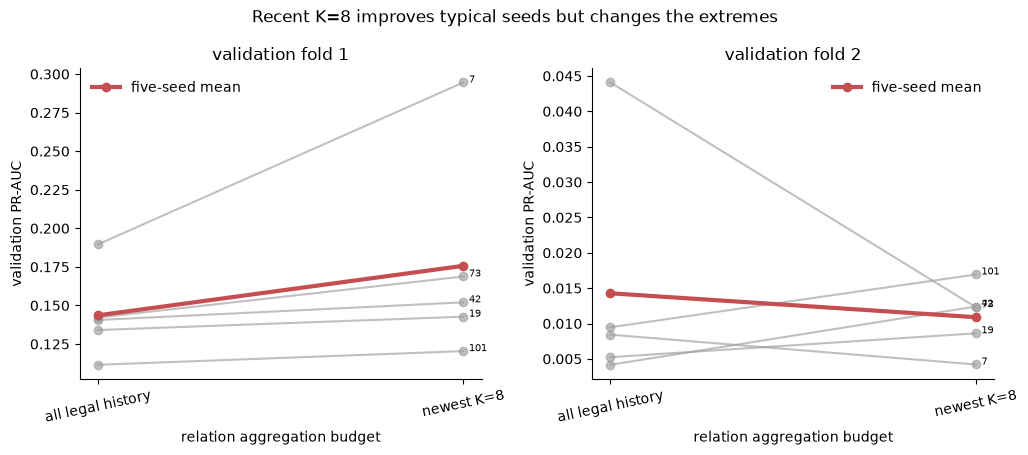

fold,aggregation,mean,median,std,min,max
1,all_history,0.1436,0.1406,0.0285,0.1115,0.1896
1,recent_k8,0.1757,0.1520,0.0687,0.1204,0.2946
2,all_history,0.0143,0.0084,0.0168,0.0042,0.0441
2,recent_k8,0.0109,0.0123,0.0048,0.0042,0.0169


In [6]:
recent = pd.read_csv(RESULTS / 'temporal_gnn_recent_ablation.csv')
plot_paired_recent_ablation(recent)
plt.show()
recent_summary = recent.groupby(['fold', 'aggregation'])['validation_pr_auc'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).reset_index()
display(recent_summary.style.format({
    name: '{:.4f}' for name in ('mean', 'median', 'std', 'min', 'max')
}).hide(axis='index'))

Recent K=8 improves the typical seed in both origins: fold-1 median rises from 0.1406 to 0.1520 and fold-2 median from 0.0084 to 0.0123. It also sharply reduces fold-2 standard deviation from 0.0168 to 0.0048. Mean ordering is mixed: recent K=8 raises fold 1 from 0.1436 to 0.1757, with one 0.2946 seed, but lowers fold 2 from 0.0143 to 0.0109 because the all-history control has one 0.0441 seed.

This is the strongest stability signal among the temporal-GNN controls, but two origins cannot establish that medians will remain better. Recent K=8 is retained as the leading candidate for additional temporal origins; the reported all-history 180-day model remains frozen, and the sealed holdout remains untouched.

## Takeaways

1. Fully empty graph history already reduces exactly to the current-invoice root path.
2. Sharing relation transforms saves roughly one-third of parameters and improves fold-2 stability, but does not dominate both origins.
3. Short decay helps the sparse fold; long or absent decay helps the denser fold.
4. The 180-day role-specific model remains frozen because selecting an origin-specific winner would be temporal tuning.
5. Recent K=8 improves both fold medians and fold-2 stability, but not both means.
6. The planned temporal-GNN component sequence is complete; recent K=8 needs more origins before promotion.